In [136]:
# Reload modules automatically
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [137]:
from pgpelib import PGPE
import numpy as np
from numbers import Real
from transformers import CLIPProcessor, CLIPModel
import torch
from sentence_transformers import SentenceTransformer
from PIL import Image
import random
import requests
from io import BytesIO
import time
from matplotlib import cm
import matplotlib.pyplot as plt
from tqdm import tqdm
from os import path
from sentence_transformers import CrossEncoder
import os
from IPython.display import display, clear_output


# Utils imports
from utils.rasterize import rasterize_shapes



DEVICE='cuda' if torch.cuda.is_available() else 'cpu'

WIDTH = 300
HEIGHT = 300

CONTENT_DIR = '/content/drive/MyDrive/dl_project/data/'
RESULTS_DIR = path.join(CONTENT_DIR, 'results')
SEGMENT_DIR = path.join(CONTENT_DIR, 'segment_img')

In [138]:
SEGMENT_IMGS = 

In [139]:
model_name = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(model_name)
model = CLIPModel.from_pretrained(model_name).to(DEVICE)
def CLIP_emb_from_IMG(IMG):
  inputs = processor(images=IMG, return_tensors="pt", padding=True).to(DEVICE)

  with torch.no_grad():
    image_features = model.get_image_features(**inputs)
    image_features = image_features / image_features.norm(dim=1, keepdim=True)

  return image_features

def CLIP_emb_from_TEXT(TEXT):
  inputs = processor(text=TEXT, return_tensors="pt", padding=True).to(DEVICE)

  with torch.no_grad():
    text_features = model.get_text_features(**inputs)
    text_features = text_features / text_features.norm(dim=1, keepdim=True)
  return text_features



: 

In [ ]:
def rasterize_shapes(shapes, positions, output_size=(800, 800)):
    """
    Rasterizes a list of shapes onto a single image, sorted by layers.
    
    Parameters:
        shapes (list of str): File paths to the PNG RGBA images.
        positions (list of tuples): A list of tuples (x, y, s, r, l) where:
                                    - x, y are normalized positions (0 to 1),
                                    - s is the normalized new scale (0 to 1),
                                    - r is a normalized rotation (0 to 1 mapped to 0-360 degrees).
                                    - l is the layer 
        output_size (tuple): Size of the output image (width, height).
    
    Returns:
        Image: A PIL Image object with all the shapes rasterized.
    """
    # Sort shapes, positions, and layers based on layer order (ascending)
    sorted_data = sorted(zip(shapes, positions), key=lambda item: item[1][-1])
    
    # Create a blank canvas with a transparent background
    canvas = Image.new("RGBA", output_size, (0, 0, 0, 0))
    width, height = output_size
    for shape, pos in sorted_data:
        x, y, s, r, _ = pos
        # Load the shape image
        shape = shape.convert("RGBA")

        # Scale the shape
        new_size = (int(shape.width * s), int(shape.height * s))
        shape = shape.resize(new_size, resample=Image.LANCZOS)
        
        # Map r from [0,1] to [0,360] degrees
        rotation_angle = r * 360

        # Rotate the shape
        rotated_shape = shape.rotate(rotation_angle, resample=Image.BICUBIC, expand=True)
        
        # Calculate the position on the canvas
        paste_x = int(x * width)
        paste_y = int(y * height)
        
        # Paste the rotated shape onto the canvas
        canvas.alpha_composite(rotated_shape, (paste_x, paste_y))
    
    return canvas

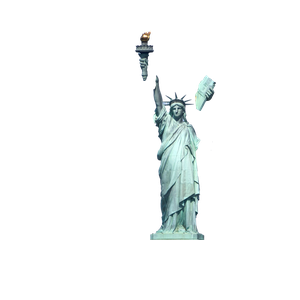

In [129]:
prompt_text = 'the statue of liberty'
prompt_embedding = CLIP_emb_from_TEXT(prompt_text)
prompt_embedding = CLIP_emb_from_IMG(SEGMENT_IMGS[prompt_text]['original'])

primitives_selected_names = list(SEGMENT_IMGS[prompt_text].keys())
primitives_selected_names.remove('original') # This is the original image aka the prompt

primitives_selected = [SEGMENT_IMGS[prompt_text][name] for name in primitives_selected_names]

# Initial solution
predictN = 5
N = len(primitives_selected)

x0 = np.ones((N, 5))
# (x, y) positions
x0[:, 0] = 1 / N * np.arange(N) + (1 / N) / 2

x0[:, 1] = 0.25

x0[0, 0] = 0.45
x0[0, 1] = 0.10

x0[2, 0] = 0.65
x0[2, 1] = 0.25
# s scale
x0[:, 2] = 0.55

x0[0, 2] = 0.17
x0[2, 2] = 0.12
# r rotation
x0[:, 3] = 0
# l layer
x0[:, 4] = x0[:, 0]
rasterize_shapes(primitives_selected, x0, (WIDTH, HEIGHT))


In [134]:
# TODO: normalize x0

pgpe = PGPE(

    # Length of each solution:
    solution_length=len(x0.flatten()),

    # Population size:
    popsize=64,

    # Initial center solution (i.e. initial mean of the search
    # distribution):
    center_init=x0.flatten(),

    # Learning rate for when updating the mean of the search distribution:
    center_learning_rate=0.003,

    # The following configuration tells that the ClipUp optimizer
    # is to be used when updating the mean of the search distribution.
    optimizer='clipup',

    # The ClipUp-specific 'max_speed' hyperparameter is set here:
    optimizer_config={'max_speed': 0.006},

    # If instead of ClipUp you would like to use Adam,
    # then set:
    #     optimizer='adam'
    # and do not specify any optimizer_config so that Adam is used
    # with its default hyperparameters.
    # For customizing how Adam works, you can also set
    # optimizer_config={'beta1': ..., 'beta2': ..., 'epsilon': ...}

    # Initial standard deviation of the search distribution
    stdev_init=0.01, # 1 ==> 0.01 per far si che gli update siamo più piccoli, ho provato 0.5 e cambia molto

    # Learning rate for when updating the standard deviation of the
    # search distribution:
    stdev_learning_rate=0.001,

    # With the setting below, the standard deviation cannot change
    # more tha then 20% of its original value.
    stdev_max_change=0.2, ###############

    # When estimating the gradient, rank the solutions linearly
    # (the ranks go from -0.5 to 0.5 from worst to best, like done
    # in the work of Salimans et al. (2017)):
    solution_ranking=True,

    # The PGPE solver will work with arrays of the following dtype:
    dtype='float32'
)

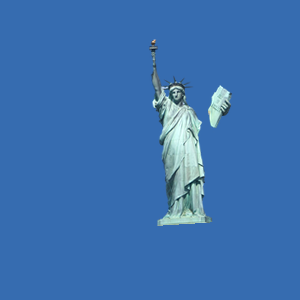

  3%|▎         | 128/5000 [09:25<5:59:00,  4.42s/it]


KeyboardInterrupt: 

In [135]:

num_iterations = 5000
report_interval = 10
i = 0

for i in tqdm(range(1, 1 + num_iterations)):
    a = time.time()
    solutions = pgpe.ask()

    rasterized_imgs = []

    b = time.time()
    for it, solution in enumerate(solutions):
      # Reshape (one for each primitive)
      solution = np.clip(solution.reshape(-1, predictN), 0.01, 1)
      img = rasterize_shapes(primitives_selected, solution, (WIDTH, HEIGHT))
      rasterized_imgs.append(Image.alpha_composite(
                                Image.new("RGBA", img.size, (54, 108, 176, 255)),  # White background
                                img
                            ).convert("RGB"))

    rasterized_imgs = np.stack(rasterized_imgs, axis=0) # (population_size, 300, 300, 4)
    rasterized_imgs = torch.tensor(rasterized_imgs).permute(0, 3, 1, 2).to(DEVICE)
    c = time.time()
    rasterized_emb = CLIP_emb_from_IMG(rasterized_imgs) # (population_size, 512)

    losses = torch.nn.functional.cosine_similarity(rasterized_emb, prompt_embedding, dim=1)

    t = time.time()
    print(f"ALL: {b-a}")
    print(f"SOL: {c-b}")
    print(f"EMB: {t-c}")
    print(f'best loss = {losses.max()}')
    print(f'avg loss = {np.average(losses)}')
    if i % 1 == 0:
      print(f'loss migliore = {losses.max()}')
      best = solutions[losses.argmax()]
      img = rasterized_imgs[losses.argmax()].cpu().numpy()
      img = np.transpose(img, (1,2,0))
      img_pil = Image.fromarray(img.astype('uint8'), 'RGB')
      #img_pil.save(path.join(RESULTS_DIR, f'img{i}.png'))
      clear_output(wait=True)  # Clear previous output
      display(img_pil)         # Display the new image

    losses = losses.cpu()
    pgpe.tell(losses)
